# Testes de Hipóteses

Este notebook parte do **dataset já tratado** (`campeonato_brasileiro_tratado.csv`, gerado em `EDA.ipynb`) e conduz **três análises formais**, com nível de significância **α = 0,05**.

> Pré-requisito: rode `EDA.ipynb` antes deste notebook, ou garanta que `Datasets/campeonato_brasileiro_tratado.csv` já existe.


## 1. Setup e carga do dataset tratado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 50)
COLORS = ["#1f6f5c", "#c0553a", "#3b6ea5", "#c9a227", "#7a5195"]

CAMINHO_TRATADO = "../Datasets/campeonato_brasileiro_tratado.csv"
FIG_DIR = "../figuras"

df = pd.read_csv(CAMINHO_TRATADO, parse_dates=["data"])
print(f"{df.shape[0]} partidas x {df.shape[1]} colunas "
      f"({df['ano'].min()}-{df['ano'].max()})")
df.head()


8405 partidas x 37 colunas (2003-2023)


,partida_id,data,ano,rodata,mandante,visitante,gols_mandante,gols_visitante,resultado,total_gols,saldo_mandante,vencedor,arena,mandante_Estado,visitante_Estado,gols_penalti_mandante,gols_penalti_visitante,gols_contra_mandante,gols_contra_visitante,cartao_amarelo_mandante,cartao_amarelo_visitante,cartao_vermelho_mandante,cartao_vermelho_visitante,chutes_mandante,chutes_visitante,chutes_no_alvo_mandante,chutes_no_alvo_visitante,escanteios_mandante,escanteios_visitante,faltas_mandante,faltas_visitante,impedimentos_mandante,impedimentos_visitante,passes_mandante,passes_visitante,posse_de_bola_mandante,posse_de_bola_visitante
0,1,2003-03-29,2003,1,Guarani,Vasco,4,2,Vitória Mandante,6,2,Guarani,Brinco de Ouro,SP,RJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2003-03-29,2003,1,Athletico-PR,Gremio,2,0,Vitória Mandante,2,2,Athletico-PR,Arena da Baixada,PR,RS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2003-03-30,2003,1,Flamengo,Coritiba,1,1,Empate,2,0,-,Maracanã,RJ,PR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2003-03-30,2003,1,Goias,Paysandu,2,2,Empate,4,0,-,Serra Dourada,GO,PA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2003-03-30,2003,1,Internacional,Ponte Preta,1,1,Empate,2,0,-,Beira Rio,RS,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Contexto: quais análises e por quê

A EDA descreveu o efeito: o mandante vence 49,7% das partidas contra 23,9% do visitante, ataca cerca de 31% mais e recebe menos cartões. Mas tudo aquilo é **estatística amostral** — descreve as 8.405 partidas observadas, não a população de jogos possíveis.

Este notebook responde às duas metades da pergunta central e investiga o mecanismo:

| Seção | Pergunta | Instrumento |
|---|---|---|
| 3 | O mando muda a probabilidade de vitória? | Teste binomial exato |
| 4 | E por quanto? | Razão de chances e pontos esperados, com IC |
| 5 | O mandante joga diferente? | Teste t pareado |
| 6 | De onde vem a vantagem? | Qui-quadrado de homogeneidade |

### Sobre a escolha dos testes

O quadro de decisão apresentado em aula indica **análise de associação** quando as variáveis independente e dependente são qualitativas nominais, que é o caso aqui (mando × resultado).

A implementação usual seria uma tabela de contingência com qui-quadrado. **Não a adotamos**, porque mandante e visitante de uma mesma partida não são observações independentes.

As Seções 3 e 5 usam, por isso, **desenhos que respeitam o pareamento** — uma observação por partida. A Seção 6 é a exceção: lá os grupos são partidas distintas em períodos diferentes, não há pareamento, e o qui-quadrado é apropriado.

### Sobre a cobertura dos dados

As colunas de estatística de jogo só têm cobertura real em 2015–2023 e já vêm como `NaN` no dataset tratado. A Seção 5 usa apenas as partidas com dado disponível; as demais usam a base completa.


## 3. Teste 1 — O mando muda a probabilidade de vitória?

**A ideia, em uma frase:** se jogar em casa não fizesse diferença, mandante e visitante venceriam metade das partidas cada um — como cara e coroa numa moeda honesta. O teste verifica se o que observamos poderia ter saído de uma moeda honesta.

**Por que excluir os empates.** Das 8.405 partidas, 2.221 terminaram empatadas. Um empate é simétrico: não favorece nem mandante nem visitante, do mesmo jeito que uma moeda caindo de pé não diz se ela é viciada. Sobram **6.184 partidas decididas**, cada uma um "cara ou coroa".

**Teste:** binomial exato
**H0:** o mando não importa — entre partidas decididas, o mandante vence com probabilidade 0,5
**H1:** a probabilidade é diferente de 0,5

O teste é chamado de *exato* porque usa a distribuição binomial diretamente, sem aproximar por uma curva normal.


In [2]:
decididas = df[df["resultado"] != "Empate"]
n_dec = len(decididas)
vit_mandante = (decididas["resultado"] == "Vitória Mandante").sum()

# O que esperaríamos se fosse uma moeda honesta
esperado = n_dec * 0.5
desvio_padrao = np.sqrt(n_dec * 0.5 * 0.5)

teste = stats.binomtest(int(vit_mandante), int(n_dec), 0.5, alternative="two-sided")
ic = teste.proportion_ci(confidence_level=0.95)

print(f"Partidas decididas (sem empate): {n_dec}")
print(f"  esperado sob H0 (moeda honesta) : {esperado:.0f} vitórias do mandante")
print(f"  observado                       : {vit_mandante} ({vit_mandante/n_dec:.1%})")
print(f"  distância                       : {(vit_mandante-esperado)/desvio_padrao:.1f} desvios-padrão")
print(f"\nIC 95% para a proporção de vitórias do mandante: [{ic.low:.1%}, {ic.high:.1%}]")
print(f"p-valor = {teste.pvalue:.2e}")
print("\nConclusão:", "Rejeita H0 — o mandante vence significativamente mais que 50% das partidas decididas."
      if teste.pvalue < 0.05 else "Não rejeita H0.")


Partidas decididas (sem empate): 6184
  esperado sob H0 (moeda honesta) : 3092 vitórias do mandante
  observado                       : 4179 (67.6%)
  distância                       : 27.6 desvios-padrão

IC 95% para a proporção de vitórias do mandante: [66.4%, 68.7%]
p-valor = 1.15e-171

Conclusão: Rejeita H0 — o mandante vence significativamente mais que 50% das partidas decididas.


### Resultado

| | |
|---|---|
| Partidas decididas | 6.184 |
| Esperado por acaso | 3.092 |
| **Observado** | **4.179 (67,6%)** |
| Distância | **27,6 desvios-padrão** |
| IC 95% | [66,4%; 68,7%] |
| p-valor | 1,15×10⁻¹⁷¹ |

**A moeda não é honesta.** O mandante venceu 4.179 das 6.184 partidas decididas — cerca de **dois terços**. Uma moeda justa produziria em torno de 3.092, e o desvio observado está a 27,6 desvios-padrão disso.

Para dar escala: sob H0, 95% das amostras teriam entre 3.015 e 3.169 vitórias do mandante. Observamos 4.179 — mais de **mil partidas** além do que o acaso explicaria.

**Sim, jogar em casa muda a probabilidade de vitória.**

**O que o p-valor não diz.** Com n = 6.184, praticamente qualquer desvio seria detectado; um p dessa ordem confirma que não é acaso, mas não informa se o efeito é grande ou pequeno. Quem responde isso é o intervalo de confiança — e, sobretudo, a próxima seção.

**Como ler o intervalo.** "Em 95% das amostras construídas dessa forma, o intervalo conteria a proporção verdadeira." Não é "há 95% de chance de a proporção estar aqui" — essa leitura é bayesiana e não se aplica ao intervalo frequentista.


## 4. Tamanho de efeito — e por quanto?

A Seção 3 estabelece que o efeito existe. Esta seção o quantifica em duas escalas, porque cada uma responde a uma pergunta diferente:

- **Diferença de proporções** — quantos pontos percentuais o mando acrescenta à chance de vitória
- **Pontos esperados por partida** — o que isso significa na tabela do campeonato

A segunda não é um teste: é a tradução do efeito para a unidade que um clube usa para decidir. Aplica a regra de pontuação do campeonato (3 pela vitória, 1 pelo empate, 0 pela derrota) às proporções observadas.

O intervalo de confiança da diferença de proporções usa a fórmula do erro-padrão para duas proporções. O dos pontos esperados vem de **bootstrap** — reamostramos as 8.405 partidas com reposição 2.000 vezes e observamos a variação do resultado, porque não há fórmula fechada para uma combinação ponderada de três proporções.


In [3]:
M = (df["resultado"] == "Vitória Mandante").sum()
E = (df["resultado"] == "Empate").sum()
V = (df["resultado"] == "Vitória Visitante").sum()
n = len(df)

# --- Diferença de proporções
p_m, p_v = M / n, V / n
se_dif = np.sqrt(p_m*(1-p_m)/n + p_v*(1-p_v)/n)
dif, dif_lo, dif_hi = p_m - p_v, p_m - p_v - 1.96*se_dif, p_m - p_v + 1.96*se_dif

# --- Pontos esperados por partida (3 vitória / 1 empate / 0 derrota)
pts_casa = (3*M + E) / n
pts_fora = (3*V + E) / n

# IC da diferença por bootstrap
mapa = {"Vitória Mandante": 3, "Empate": 0, "Vitória Visitante": -3}
saldo_pts = df["resultado"].map(mapa).values
rng = np.random.default_rng(42)
boot = np.array([rng.choice(saldo_pts, len(saldo_pts), replace=True).mean() for _ in range(2000)])
pts_lo, pts_hi = np.percentile(boot, [2.5, 97.5])

print(f"Vitórias: mandante {M} ({p_m:.1%}) | empates {E} | visitante {V} ({p_v:.1%})\n")
print(f"Diferença de proporções : {dif:.1%}  IC95 [{dif_lo:.1%}, {dif_hi:.1%}]")
print(f"\nPontos esperados por partida em casa : {pts_casa:.3f}")
print(f"Pontos esperados por partida fora    : {pts_fora:.3f}")
print(f"Vantagem do mando                    : {pts_casa - pts_fora:.3f} ponto/jogo"
      f"  IC95 [{pts_lo:.3f}, {pts_hi:.3f}]")
print(f"\nEm 19 jogos em casa por temporada    : {(pts_casa-pts_fora)*19:.1f} pontos"
      f"  IC95 [{pts_lo*19:.1f}, {pts_hi*19:.1f}]")


Vitórias: mandante 4179 (49.7%) | empates 2221 | visitante 2005 (23.9%)

Diferença de proporções : 25.9%  IC95 [24.5%, 27.3%]

Pontos esperados por partida em casa : 1.756
Pontos esperados por partida fora    : 0.980
Vantagem do mando                    : 0.776 ponto/jogo  IC95 [0.725, 0.832]

Em 19 jogos em casa por temporada    : 14.7 pontos  IC95 [13.8, 15.8]


### Resultado

| Medida | Valor | IC 95% |
|---|---|---|
| Diferença de proporções | **25,9 p.p.** | [24,5; 27,3] |
| Vantagem em pontos por partida | **0,776** | [0,725; 0,832] |
| Vantagem em 19 jogos em casa | **14,7 pontos** | [13,8; 15,8] |

**Como ler.** Jogar em casa acrescenta cerca de **26 pontos percentuais** à probabilidade de vitória: de 23,9% como visitante para 49,7% como mandante. O intervalo não inclui zero, o que é consistente com a rejeição da Seção 3.

**A tradução que importa para a decisão:** o mando vale **0,78 ponto por partida**. Ao longo de uma temporada de pontos corridos, com 19 jogos em casa, isso soma aproximadamente **14,7 pontos** — uma diferença da ordem de várias posições na tabela final do Brasileirão.

**Sobre o intervalo de confiança.** A leitura correta é: em 95% das amostras construídas dessa forma, o intervalo conteria o valor populacional. Não é "há 95% de chance de o valor estar aqui" — essa interpretação é bayesiana e não se aplica ao intervalo frequentista.

**O que isto não estabelece.** Que o mando *cause* a vantagem por algum mecanismo específico. A magnitude está medida; a explicação é o assunto das duas próximas seções.


## 5. Teste 2 — O mandante joga diferente?

**A ideia:** em cada partida, comparamos a estatística do mandante com a do visitante **no mesmo jogo**. Como os dois enfrentaram o mesmo gramado, o mesmo árbitro e o mesmo clima, qualquer diferença sistemática é atribuível ao mando. É o mesmo princípio de pareamento da Seção 3.

Testamos duas métricas escolhidas por medirem coisas diferentes: **chutes** mede volume ofensivo, **posse de bola** mede controle do jogo. O contraste entre as duas é o que interessa. Chutes no alvo e escanteios foram omitidos por repetirem o comportamento de chutes — os três sobem na mesma proporção, e a EDA já os documenta.

O quadro de decisão da disciplina indica, para variável independente qualitativa nominal e dependente quantitativa, comparação **paramétrica ou não paramétrica conforme a normalidade**. Verificamos a normalidade das diferenças e reportamos assimetria e curtose na tabela: ambas ficam dentro da faixa de distribuições bem comportadas (módulo abaixo de ~1). Somado a isso, com n ≈ 3.400 o Teorema Central do Limite garante que a média amostral é aproximadamente normal mesmo que as diferenças individuais não fossem. Adotamos portanto o **teste t de Student pareado**.

**H0:** a média da diferença (mandante − visitante) é zero
**H1:** a média da diferença é diferente de zero


In [4]:
metricas = ["chutes", "posse_de_bola"]
linhas = []

for metrica in metricas:
    sub = df[[f"{metrica}_mandante", f"{metrica}_visitante"]].dropna()
    dif = sub[f"{metrica}_mandante"] - sub[f"{metrica}_visitante"]
    t_stat, p_t = stats.ttest_rel(sub[f"{metrica}_mandante"], sub[f"{metrica}_visitante"])
    linhas.append({
        "métrica": metrica,
        "n": len(sub),
        "média mandante": round(sub[f"{metrica}_mandante"].mean(), 2),
        "média visitante": round(sub[f"{metrica}_visitante"].mean(), 2),
        "razão M/V": round(sub[f"{metrica}_mandante"].mean() / sub[f"{metrica}_visitante"].mean(), 3),
        "assimetria": round(stats.skew(dif), 2),
        "curtose": round(stats.kurtosis(dif), 2),
        "p (t pareado)": p_t,
        "Cohen's d": round(dif.mean() / dif.std(), 3),
    })

tabela_testes = pd.DataFrame(linhas)
tabela_testes


,métrica,n,média mandante,média visitante,razão M/V,assimetria,curtose,p (t pareado),Cohen's d
0,chutes,3419,14.52,11.10,1.308,0.09,0.09,3.053715e-140,0.452
1,posse_de_bola,3394,51.72,48.28,1.071,-0.12,-0.49,2.554864e-21,0.164


### Resultado

| Métrica | Mandante | Visitante | Razão | Cohen's d |
|---|---|---|---|---|
| **Chutes** | 14,52 | 11,10 | **1,31** | **0,45** |
| **Posse de bola** | 51,72% | 48,28% | 1,07 | 0,16 |

As colunas de assimetria e curtose confirmam o pressuposto: ambas as diferenças ficam dentro da faixa em que o teste t é adequado. Nas duas métricas o p-valor é extremamente pequeno — H0 é rejeitada.

**O contraste é o achado.** O mandante chuta **31% mais**, com efeito de tamanho médio (d = 0,45). Mas a posse de bola sobe apenas 7%, com efeito pequeno (d = 0,16). Ou seja: o mandante **não controla mais o jogo** — ele **arrisca mais**.

Combinado com o dado da EDA de que a taxa de conversão é praticamente idêntica (26,2% contra 25,9%), a leitura fica clara: **o mandante não joga melhor, joga mais adiantado.** Aponta para pressão territorial e iniciativa, não para superioridade técnica — o que faz sentido, já que é o mesmo elenco que atua fora de casa.


## 6. Teste 3 — De onde vem a vantagem? O período de portões fechados

As seções anteriores mostram que a vantagem existe, medem seu tamanho e descrevem como ela se manifesta em campo. Falta a pergunta que a Seção 8 da EDA deixou explicitamente em aberto: **de onde vem essa vantagem?**

A literatura aponta quatro candidatos — familiaridade com o campo, desgaste da viagem do visitante, apoio da torcida aos jogadores e influência da torcida sobre a arbitragem. Os quatro produzem o mesmo resultado agregado, então não são distinguíveis pelos dados que usamos até aqui.

**O quase-experimento.** Entre agosto de 2020 e setembro de 2021, as partidas foram disputadas sem público por determinação sanitária. A torcida desapareceu sem que familiaridade com o campo ou desgaste de viagem mudassem, e a remoção não foi escolha dos clubes — foi imposta externamente, o que afasta a autosseleção. É a aproximação mais próxima de um experimento controlado que estes dados permitem.

**Previsões concorrentes:**
- Se a torcida (sobre jogadores ou sobre a arbitragem) for o mecanismo dominante, a vantagem deve **encolher** no período sem público e **voltar** depois.
- Se familiaridade e viagem dominarem, a vantagem deve **permanecer estável**, já que nenhuma delas depende de público.

**Teste:** qui-quadrado de homogeneidade (3 períodos × 3 resultados)
**H0:** a distribuição dos resultados é a mesma nos três períodos
**H1:** ao menos um período difere

Aqui, diferentemente das seções anteriores, os grupos são **partidas distintas** — não há pareamento, e a premissa de independência do qui-quadrado é satisfeita.

**Definição dos períodos.** O retorno do público foi gradual e variou por estado, então as datas de corte são aproximadas e as partidas do período de transição (out/2021 a nov/2021) são excluídas em vez de atribuídas arbitrariamente a um dos grupos.


Partidas excluídas (suspensão do campeonato e transição do público): 140

resultado         Vitória Mandante  Empate  Vitória Visitante
periodo                                                      
Com público                   3488    1794               1603
Portões fechados               252     178                164
Público de volta               361     212                213

Distribuição percentual:
resultado         Vitória Mandante  Empate  Vitória Visitante
periodo                                                      
Com público                   50.7    26.1               23.3
Portões fechados              42.4    30.0               27.6
Público de volta              45.9    27.0               27.1

Chi2 = 20.98 | gl = 4 | p-valor = 3.20e-04
Menor frequência esperada: 142.3 (premissa exige >= 5)

Conclusão: Rejeita H0 — a distribuição dos resultados difere entre os períodos.

Taxa de vitória do mandante, com IC 95%:
  Com público          n= 6885   50.7%  IC95 [49.5%, 51.8%

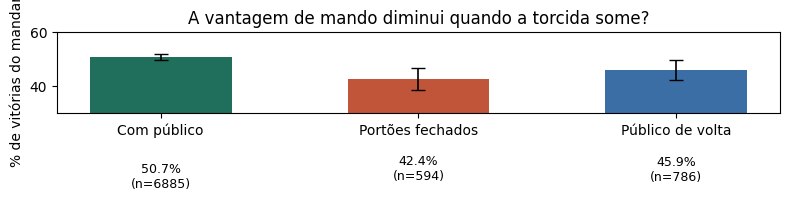

In [5]:
df["periodo"] = pd.NA
df.loc[df["data"] <  "2020-03-01", "periodo"] = "Com público"
df.loc[(df["data"] >= "2020-08-08") & (df["data"] <= "2021-09-30"), "periodo"] = "Portões fechados"
df.loc[df["data"] >= "2021-12-01", "periodo"] = "Público de volta"

excluidas = df["periodo"].isna().sum()
sub = df[df["periodo"].notna()]
ordem = ["Com público", "Portões fechados", "Público de volta"]

tabela = pd.crosstab(sub["periodo"], sub["resultado"]).loc[
    ordem, ["Vitória Mandante", "Empate", "Vitória Visitante"]]
print(f"Partidas excluídas (suspensão do campeonato e transição do público): {excluidas}\n")
print(tabela.to_string())
print("\nDistribuição percentual:")
print((tabela.div(tabela.sum(axis=1), axis=0) * 100).round(1).to_string())

chi2, p_val, gl, esperado = stats.chi2_contingency(tabela)
print(f"\nChi2 = {chi2:.2f} | gl = {gl} | p-valor = {p_val:.2e}")
print(f"Menor frequência esperada: {esperado.min():.1f} (premissa exige >= 5)")
print("\nConclusão:", "Rejeita H0 — a distribuição dos resultados difere entre os períodos."
      if p_val < 0.05 else "Não rejeita H0.")

print("\nTaxa de vitória do mandante, com IC 95%:")
taxas = []
for per in ordem:
    k, nn = tabela.loc[per, "Vitória Mandante"], tabela.loc[per].sum()
    r = stats.binomtest(int(k), int(nn), 0.5).proportion_ci(confidence_level=0.95)
    taxas.append((per, nn, k/nn, r.low, r.high))
    print(f"  {per:20s} n={nn:5d}  {k/nn:6.1%}  IC95 [{r.low:.1%}, {r.high:.1%}]")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(taxas))
vals = [t[2]*100 for t in taxas]
erros = [[(t[2]-t[3])*100 for t in taxas], [(t[4]-t[2])*100 for t in taxas]]
ax.bar(x, vals, color=[COLORS[0], COLORS[1], COLORS[2]], width=0.55)
ax.errorbar(x, vals, yerr=erros, fmt="none", ecolor="black", capsize=5, lw=1.2)
for i, (per, nn, v, lo, hi) in enumerate(taxas):
    ax.text(i, v + (hi-v)*100 + 1.2, f"{v:.1%}\n(n={nn})", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([t[0] for t in taxas])
ax.set_ylabel("% de vitórias do mandante")
ax.set_ylim(30, 60)
ax.set_title("A vantagem de mando diminui quando a torcida some?", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/portoes_fechados.png", dpi=150)
plt.show()


### Resultado

| Período | n | Vitória mandante | IC 95% |
|---|---|---|---|
| Com público (até mar/2020) | 6.885 | **50,7%** | [49,5%; 51,8%] |
| Portões fechados (ago/2020–set/2021) | 594 | **42,4%** | [38,4%; 46,5%] |
| Público de volta (dez/2021 em diante) | 786 | **45,9%** | [42,4%; 49,5%] |

χ² = 20,98, gl = 4, **p = 3,2×10⁻⁴**. Rejeita-se H0: a distribuição de resultados não é a mesma nos três períodos.

**O intervalo do período sem público não se sobrepõe ao do período com público.** A queda de 8,3 pontos percentuais é maior que a incerteza das duas estimativas, o que sustenta que a diferença não é ruído amostral.

**Interpretação.** O resultado é compatível com a hipótese de que a torcida é um componente relevante da vantagem de mando. Mas o efeito **não desaparece**: mesmo sem público, o mandante venceu 42,4% contra 27,6% do visitante. Sobra uma vantagem substancial, atribuível aos mecanismos que não dependem de torcida — familiaridade com o campo e desgaste da viagem.

**Sobre o retorno.** O período com público de volta (45,9%) fica entre os outros dois, e seu intervalo se sobrepõe a ambos. Ou seja: **a recuperação é sugestiva, mas não conclusiva**. Com n = 786 não é possível afirmar que a vantagem voltou ao patamar anterior.

**O que este teste NÃO permite concluir.** Que a torcida influencia a arbitragem. O desenho separa "torcida" de "familiaridade e viagem", mas não separa "torcida influencia os jogadores" de "torcida influencia o árbitro" — os dois somem juntos quando o estádio esvazia.

**Limitação do quase-experimento.** O calendário de 2020–21 foi anômalo em vários eixos simultâneos: ausência de pré-temporada, jogos condensados, elencos desfalcados por surtos e afastamentos. Não é possível isolar cirurgicamente o efeito "ausência de torcida" do efeito "temporada atípica". O desenho é forte porque a remoção do público foi externa e não escolhida pelos clubes, mas não é um experimento controlado.


## 7. Síntese e resposta à pergunta central

| # | Análise | H0 | Resultado | Decisão |
|---|---|---|---|---|
| 1 | Binomial exato | Mandante vence 50% das decididas | 67,6%, IC95 [66,4%; 68,7%]; p ≈ 1,1×10⁻¹⁷¹ | Rejeita H0 |
| 2 | Tamanho de efeito | — | 25,9 p.p. [24,5; 27,3]; 0,776 pt/jogo [0,725; 0,832] | — |
| 3 | t pareado | Médias iguais em chutes e posse | p < 0,001 nas duas; d = 0,45 e 0,16 | Rejeita H0 |
| 4 | Qui-quadrado de homogeneidade | Resultados iguais nos três períodos | 50,7% → 42,4% → 45,9%; p = 3,2×10⁻⁴ | Rejeita H0 |

### Resposta à pergunta do Tema 8

> *Jogar em casa realmente muda a probabilidade de vitória, e por quanto?*

**Muda.** Entre as partidas decididas, o mandante vence 67,6% (IC 95% [66,4%; 68,7%]) — dois terços. A hipótese de equilíbrio é rejeitada com folga, e o efeito é positivo em todas as 21 temporadas analisadas.

**Por quanto:** o mando acrescenta cerca de **26 pontos percentuais** à probabilidade de vitória e vale **0,78 ponto por partida** — aproximadamente **14,7 pontos** ao longo dos 19 jogos em casa de uma temporada.

**De onde vem:** o mandante ataca 31% mais sem ser mais eficiente e sem controlar mais o jogo, o que aponta para pressão territorial e não para superioridade técnica. E a vantagem cai de 50,7% para 42,4% quando os estádios esvaziam, o que identifica a torcida como componente relevante — embora não exclusivo, já que uma vantagem substancial permanece mesmo sem público.

### Limitações

- Os intervalos de confiança pressupõem partidas independentes. Há dependência residual não modelada: times enfrentam adversários de forças diferentes, e o desempenho de um clube é correlacionado ao longo da temporada. O intervalo real é provavelmente um pouco mais largo que o reportado.
- A série cobre 2003–2023 e descreve o Campeonato Brasileiro. Generalizar para outras ligas exigiria replicação.
- As estatísticas de jogo só existem em 2015–2023, então a Seção 5 descreve o período recente, não as 21 temporadas.
- O período de portões fechados coincide com uma temporada atípica em vários aspectos além da ausência de público.
- Nenhuma das análises estabelece causalidade em sentido estrito. O quase-experimento da Seção 6 é o desenho mais próximo disso, e ainda assim carrega as ressalvas acima.
